# Day 14(M4 Day01) 실습 — LangGraph State·Node·Edge와 흐름 제어 기초

**목표**: State·Node·Edge로 기본 그래프를 만들고, 조건 분기·반복(루프)을 구현하며, 도구 에이전트를 그래프로 재구성한다.
**구성**: Part 1 기본 그래프(+엣지·State 오류 2종) → Part 2 조건 분기·반복(+재귀 한도 재현+재고 확인 도메인 반복) → Part 3 도구 에이전트 재구성(+M1 Day04 방어+M3 Day01 지식 검색을 결합한 LangGraph 면접 코치)

> **참고:** 실습 전 가상환경 활성화, `.env`의 `OPENAI_API_KEY`를 확인한다. `uv add langgraph`가 필요하다(이미 설치돼 있다면 생략). 오늘부터 M4(흐름 제어) 모듈이다 — llm-dev의 마지막 모듈이다.

### 시작 전에 — 에이전트와 워크플로, 무엇이 다른가

오늘부터 배우는 LangGraph는 **개발자가 흐름을 미리 고정한 워크플로**를 만드는 도구다. M2에서 배운 `create_agent`는 반대로 **LLM이 매 순간 다음 행동을 스스로 정하는 자유형 에이전트**였다.

| | 자유형 에이전트(M2 `create_agent`) | 고정 워크플로(오늘부터 LangGraph) |
| --- | --- | --- |
| 경로 | 매번 LLM이 판단해서 정함 | 개발자가 미리 정해둠 |
| 신뢰성·재현성 | 같은 입력에도 경로가 달라질 수 있음 | 항상 같은 경로를 탐 |
| 비용 | LLM이 판단할 때마다 호출 발생 | 필요한 지점에서만 호출 |
| 디버깅 | 실패 지점을 특정하기 어려움 | 어느 노드에서 실패했는지 바로 보임 |
| 적합한 상황 | 태스크의 경로 자체가 불확실할 때 | 태스크의 경로가 미리 알려져 있을 때 |

에이전트의 자율성은 **경로가 불확실할 때만** 값어치가 있다. "무엇을 언제 어떤 순서로 할지" 미리 아는 작업이라면, 매번 LLM이 판단하게 두는 것보다 고정된 흐름(오늘 배울 LangGraph)이 더 저렴하고 예측 가능하다.

## 0. 환경 준비

In [1]:
import os, operator
os.environ["LANGSMITH_TRACING"] = "false"
os.environ["LANGCHAIN_TRACING_V2"] = "false"

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END

print("준비 완료")

준비 완료


## Part 1. 기본 그래프 — 기초

완성 코드를 직접 쳐서 State를 정의하고, 노드·엣지를 이어 그래프를 실행한다.

### 1-1. State 정의

흐름을 오가며 들고 다닐 값을 정한다(text는 덮어쓰기, steps는 누적).

In [2]:
class Person(TypedDict):
    name: str
    age: int

In [4]:
user: Person = {"name": "Alice", "age": 30}
user, type(user)

({'name': 'Alice', 'age': 30}, dict)

In [5]:
# TODO: text(str)는 덮어쓰기, steps(list, operator.add로 누적)를 담는 State(TypedDict)를 정의하세요

class State(TypedDict):
    text: str
    steps: Annotated[list, operator.add]

print("State 정의 완료")

State 정의 완료


In [6]:
state: State = {
    "text": "Hello",
    "steps": ["start"]
}
state

{'text': 'Hello', 'steps': ['start']}

### 1-2. 노드 작성·추가

노드는 State를 받아 바뀐 값만 돌려주는 함수다.

In [7]:
def clean(s): return {"text":s["text"].strip(), "step":["clean"]}
def upper(s): return {"text":s["text"].upper(), "step":["upper"]}

In [8]:
# TODO: State로 StateGraph를 만들고(g), clean·upper 노드를 add_node로 추가하세요

g = StateGraph(State) # state 딕셔너리를 들고 다니는 그래프 생성
g.add_node("clean", clean)
g.add_node("upper", upper)

print("노드 추가 완료")

노드 추가 완료


In [10]:
g.state_schema

__main__.State

### 1-3. 엣지 연결·컴파일

START에서 시작해 노드를 잇고 END로 끝낸다.

In [11]:
# TODO: START->clean->upper->END 순서로 add_edge를 이어 app = g.compile()로 완성하세요
g.add_edge(START, "clean")
g.add_edge("clean", "upper")
g.add_edge("upper", END)

app = g.compile()

print("그래프 완성")

그래프 완성


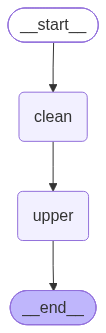

In [12]:
app

### 1-4. 실행·State 변화 관찰

text가 정리·대문자화되고 steps가 누적되는지 본다.

In [ ]:
# TODO: app.invoke로 {"text": "  hello  ", "steps": []}를 실행해 result에 저장하세요


print(result)

### 1-5. 그래프 구조 보기

`draw_mermaid()`로 상자-화살표 구조를 문자열로 출력한다.

### 1-6. 오류 대응 ① — 존재하지 않는 노드로 엣지를 연결하면?

`add_node`로 추가하지 않은 이름을 `add_edge`의 목적지로 쓰면 어떻게 되는지 확인한다.

In [ ]:

# TODO: 존재하지 않는 노드 이름("ghost_node")으로 add_edge("f", "ghost_node")를 하고 compile해보세요


> **주의:** 결과는 실제 실행에서 직접 확인한다. 엣지는 실제로 존재하는 노드끼리만 이을 수 있다 — `compile()` 시점에 그래프 구조 자체를 검증하기 때문에, 노드 이름 오타는 실행 전에 걸러진다.

### 1-7. 오류 대응 ② — State에 필수 키를 빠뜨리고 실행하면?

`invoke()`에 State가 요구하는 키를 안 넣으면 어떻게 되는지 확인한다.

In [ ]:


# TODO: 필수 키 text를 빼고 app3.invoke({})를 실행해 r3에 저장해보세요


> **주의:** 결과는 실제 실행에서 직접 확인한다. `TypedDict`는 파이썬 타입 힌트일 뿐 강제 검증이 아니다 — 노드 함수 안에서 실제로 그 키에 접근하는 순간(`s["text"]`) 없으면 오류가 난다. `compile()` 단계가 아니라 **그 키를 실제로 쓰는 노드가 실행되는 시점**에 드러난다.

### 관찰 정리

- 1-6·1-7에서 확인한 두 오류는 각각 언제(컴파일 시점 vs 실행 시점) 드러났는가?
- 노드가 State에 없는 키를 돌려주면 어떻게 될까? (직접 실험해 보아도 좋다)

## Part 2. 조건 분기·반복 — 응용

State를 보고 다음 상자를 고르고(분기), 조건이 찰 때까지 되돌아간다(반복).

### 2-1. 조건 분기 — 갈림길

조건 함수가 State를 보고 다음 노드 이름을 돌려준다.

In [ ]:

# TODO: State의 n이 짝수면 "even", 홀수면 "odd"를 반환하는 route 함수를 만드세요




# TODO: check 다음에 route로 분기해 "even"/"odd" 노드로 보내는 add_conditional_edges를 만드세요





### 2-2. 반복(루프) — 되돌아가기

조건 엣지로 자기 자신에게 되돌아가면 반복이 된다.

In [ ]:
# TODO: n<3이면 "tick", 아니면 "end"를 반환하는 cont 함수를 만드세요


# TODO: tick 다음에 cont로 분기해 "tick"이면 자기 자신, "end"면 END로 보내는
#       add_conditional_edges를 만드세요





### 2-3. 재귀 한도 초과 재현

종료 조건이 없는 루프를 만들어 무한 반복이 실제로 막히는지 확인한다.

In [ ]:

# TODO: app_l2.invoke로 {"n": 0, "steps": []}인 무한 루프를 실행해 r_forever에 저장하세요


> **참고:** 결과는 실제 실행에서 직접 확인한다. 종료 조건 없는 루프는 LangGraph의 재귀 한도에 걸려 오류로 멈춘다 — 그래도 이 한도에 기대지 말고, **항상 직접 종료 조건을 설계**해야 한다(2-2처럼).

### 관찰 정리

| 흐름 | 구성 | 멈추는 법 |
| --- | --- | --- |
| 분기 | 조건 함수 → 노드 지도 | 각 갈래가 END로 |
| 반복 | 조건 엣지가 자기에게 회귀 | 종료 조건이 "end" 반환 |

### 2-4. 다른 도메인 반복 — 재고 확인·재입고 흐름

같은 방법(분기+반복)을 다른 도메인에도 적용해본다. 이번엔 재고량에 따라 분류하고, 부족하면 재입고를 반복한다.

In [ ]:

# TODO: stock이 10 초과면 "normal", 0 초과면 "low", 그 외엔 "out"을 반환하는 route_stock 함수를 만드세요





# TODO: stock이 10 미만이면 "restock", 아니면 "done"을 반환하는 restock_route 함수를 만드세요




### 관찰 정리

- 숫자 홀짝 도메인과 재고 도메인 모두에서, 분기·반복 구조가 그대로 통했는가?
- `restock` 루프는 몇 번 반복하고 멈췄는가? 종료 조건은 무엇이었는가?

### 2-5. 병렬화 — Send로 동시에 처리하기

지금까지의 분기는 여러 갈래 중 **하나**를 골랐다. 병렬화는 여러 갈래를 **동시에 전부** 실행하고 결과를 모으는 것이다 — 서로 독립적인 하위 작업(예: 리뷰를 여러 관점에서 평가)에 적합하다.

In [ ]:


# TODO: aspects 각각에 대해 evaluate_aspect 노드를 독립적으로(병렬로) 실행하도록
#       Send("evaluate_aspect", {...}) 리스트를 반환하는 fan_out 함수를 작성하세요




### 2-6. 오케스트레이터-워커 — 매니저가 작업을 나누고 워커가 처리하기

2-5의 병렬화는 `aspects` 목록을 **미리 정해서** 넘겼다. 오케스트레이터-워커는 그 목록 자체를 **매니저 LLM이 그때그때 정하고**, 정해진 하위 작업들을 워커 LLM들에게 나눠 맡긴 뒤 결과를 종합한다.

In [ ]:

# TODO: 이 작업을 검토할 하위 관점 2~4개를 한 줄에 하나씩만 나열하도록 llm.invoke로 요청하고,
#       줄 단위로 나눠 subtasks 리스트를 만드는 orchestrator 함수를 작성하세요
#       (참고: plan.strip().split("\n")으로 줄 단위 분리)



## Part 3. 미니 프로젝트 — 도구 에이전트를 그래프로 재구성

M2 Day04(Day08)의 `create_agent`가 내부에서 하던 일을, State·Node·Edge로 직접 조립한다.

### 3-1. 도구·모델·State

메시지를 누적하는 State와 도구를 붙인 LLM을 준비한다.

In [ ]:
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

@tool
def add(a: int, b: int) -> int:
    """두 수를 더한다."""
    return a + b

# TODO: add 도구를 bind_tools한 ChatOpenAI(temperature=0)를 llm_tools에 만들고
#       tool_map = {"add": add}를 만드세요





### 3-2. 노드·조건 엣지

llm(판단)·tools(실행) 노드와, 도구 호출 여부로 분기하는 조건 엣지를 만든다.

In [ ]:


# TODO: 마지막 메시지에 tool_calls가 있으면 "tools", 없으면 "end"를 반환하는 agent_route 함수를 만드세요

# 
# 기해 "tools"/"end"로 보내는 add_conditional_edges를 만들고
#       tools에서 다시 llm으로 돌아가는 add_edge를 추가하세요



print("에이전트 그래프 완성")

### 3-3. 실행·경로 확인

### 관찰

| 메시지 | 역할 |
| --- | --- |
| HumanMessage | 사용자 질문 |
| AIMessage(tool_calls) | LLM이 도구 호출 결정 |
| ToolMessage | 도구 실행 결과 |
| AIMessage | 근거로 만든 최종 답 |

## Part 3-확장. M1·M3 통합 — LangGraph 기반 면접 코치

위 도구 에이전트 그래프에, M3 Day01(Day10)의 임베딩 채용 공고 검색을 **도구**로 붙이고, M1 Day04의 입력·출력 방어를 그래프 바깥에서 감싼다. `create_agent` 없이도 같은 일을 그래프로 할 수 있음을 확인한다.

### 채용 공고 검색 도구 (M3 Day01 재사용)

In [ ]:
from langchain_openai import OpenAIEmbeddings
import numpy as np

emb = OpenAIEmbeddings(model="text-embedding-3-small")
job_postings = [
    "백엔드 개발자: Python/Java 기반 서버 개발, RESTful API 설계, DB 최적화 경험 우대",
    "프론트엔드 개발자: React/TypeScript, 반응형 UI 구현, 웹 접근성 이해 우대",
    "데이터 분석가: SQL/Python 데이터 분석, 대시보드 제작, 통계적 사고 우대",
    "마케터: 콘텐츠 기획, 데이터 기반 캠페인 분석, SNS 채널 운영 경험 우대",
]
# TODO: job_postings를 embed_documents로 임베딩해 job_vectors에 저장하세요


def cosine(a, b):
    a, b = np.array(a), np.array(b)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

@tool
def search_job(interest: str) -> str:
    """관심 직무 설명을 받아 가장 관련 있는 채용 공고를 검색한다."""
    # TODO: interest를 embed_query로 벡터화하고, job_postings와의 코사인 유사도로 정렬해
    #       가장 관련 있는 공고 1개를 반환하세요




print("채용 공고 검색 도구 준비 완료")

### 방어 로직 (M1 Day04 재사용)

인젝션 방어는 M1 Day04에서 만든 것을 그대로 가져온다.

In [ ]:
# TODO: M1 Day04의 위험 문구·금지어 목록과 input_guard·output_guard를 옮겨오세요






### LangGraph 기반 면접 코치

`search_job` 도구를 붙인 새 그래프를 만들고, 방어 로직으로 감싼다.

In [ ]:

# TODO: '지원자가 관심 직무를 말하면 search_job으로 검색해 참고한다'는 SystemMessage와 question으로
#       coach_graph를 invoke해 answer를 만드세요





### 최종 테스트

In [ ]:


# TODO: 인젝션을 시도하는 질문을 넣어보세요

### M4 Day01 정리

**확인 질문**
- `graph_coach`에서 M1·M2·M3·오늘(M4) 각각에서 가져온 요소는 무엇인가?
- `create_agent`(M2)로 만든 코치와 오늘 그래프로 직접 만든 코치는 겉보기 동작이 같은가? 내부 구현은 어떻게 다른가?

## 확인 문제

1. 노드는 State 전체를 돌려주는가, 바뀐 부분만 돌려주는가?
2. 1-6·1-7에서 확인한 두 오류는 각각 언제(컴파일 시점 vs 실행 시점) 드러났는가?
3. 2-3에서 확인한 것처럼, 종료 조건 없는 루프는 어떻게 멈추는가? 이 한도에 기대도 되는가?
4. Part 2와 Part 2의 도메인 반복에서, 분기·반복 구조가 도메인이 달라도 그대로 통했는가?
5. `graph_coach`에서 도구 호출 후 왜 항상 다시 `llm` 노드로 돌아가는가?